<a href="https://colab.research.google.com/github/albinvar/hydrolink-plus/blob/firmware/Water_Consumption_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Discussion

## RMSE vs. MAE

**Are these spikes important to you to be predicted correctly?**

**For example, for the solar storms project, exactly these spikes were very important.**

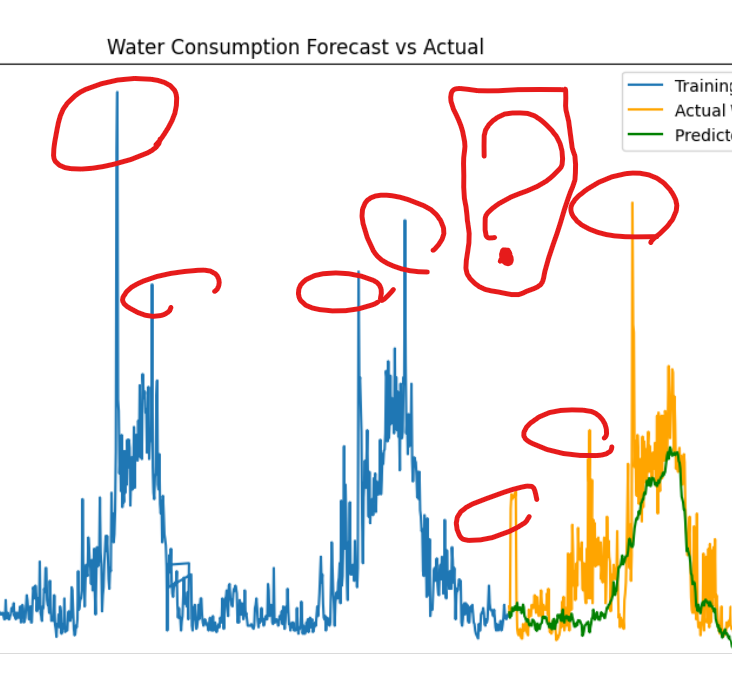

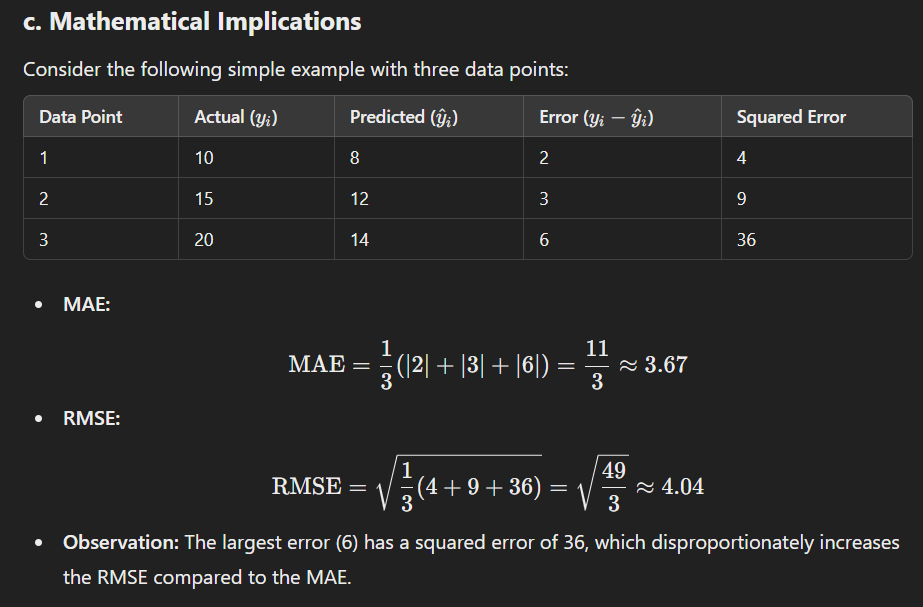

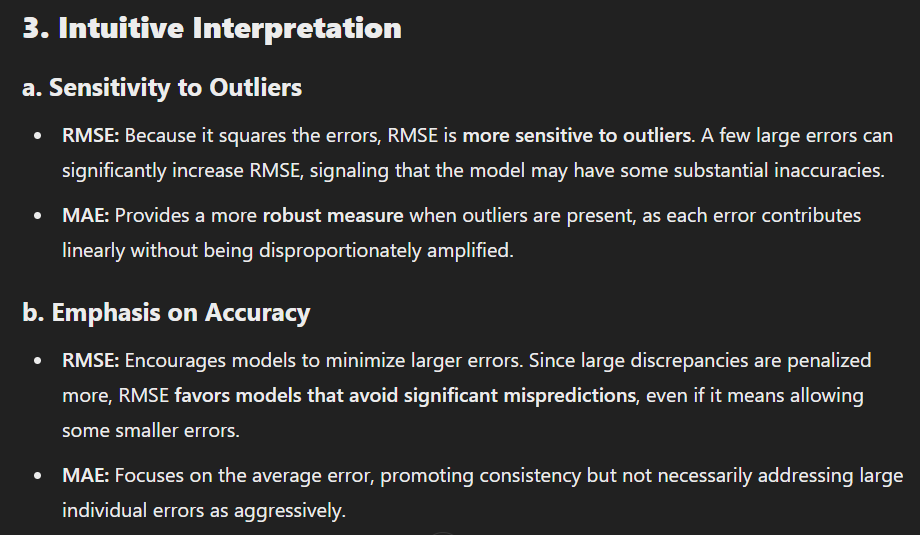

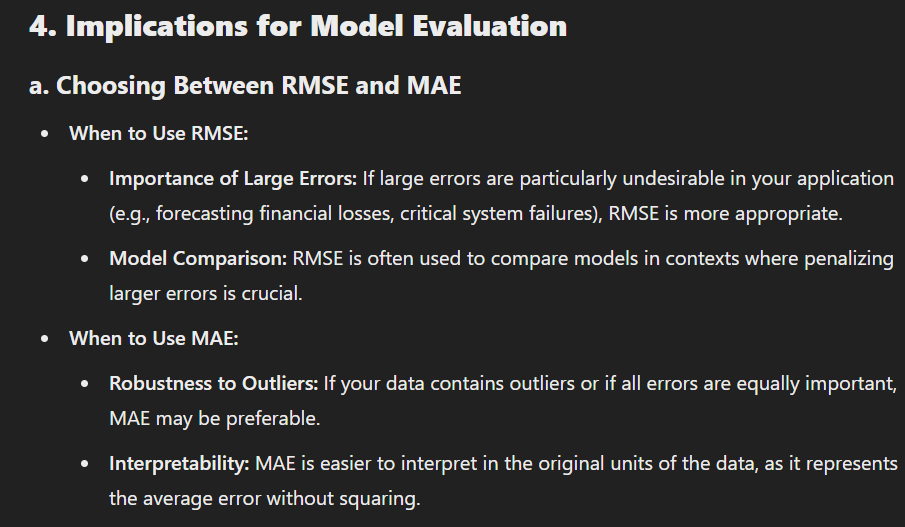

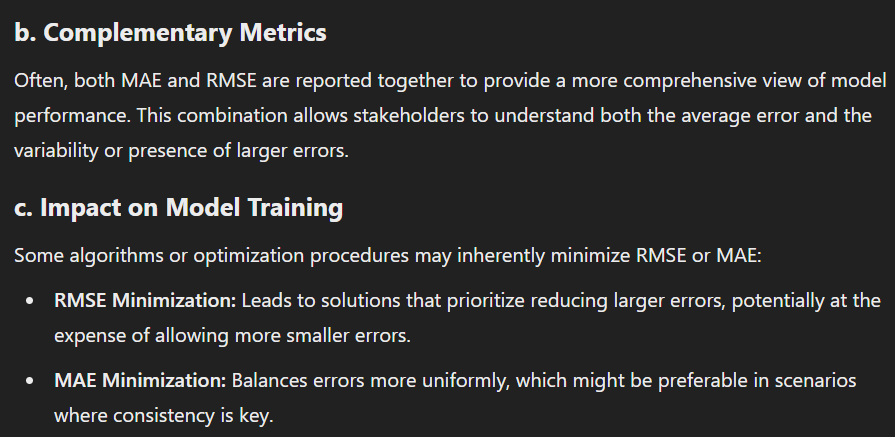

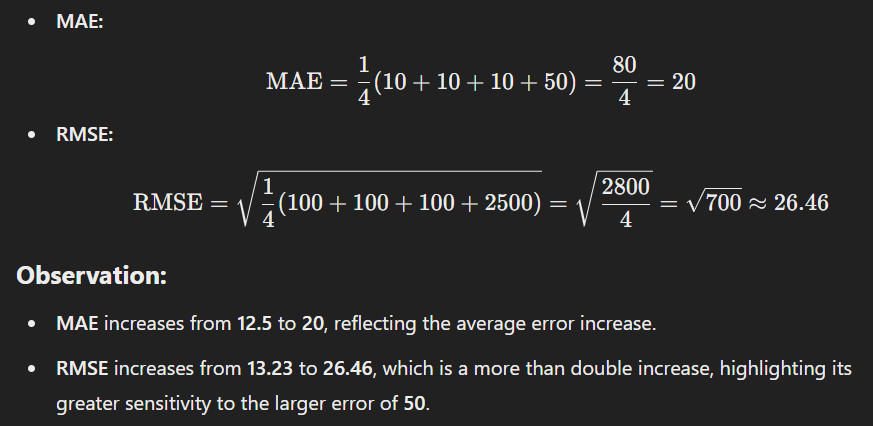

# Method 1: prophet

<ipython-input-1-0325585c6e7d>:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[regressors] = df[regressors].fillna(method='ffill')
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 0.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/ja7t3daq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/jq0eoj22.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76391', 'data', 'file=/tmp/tmp767bzkcs/ja7t3daq.json', 'init=/tmp/tm

Mean Absolute Error: 274.19
Root Mean Squared Error: 283.51


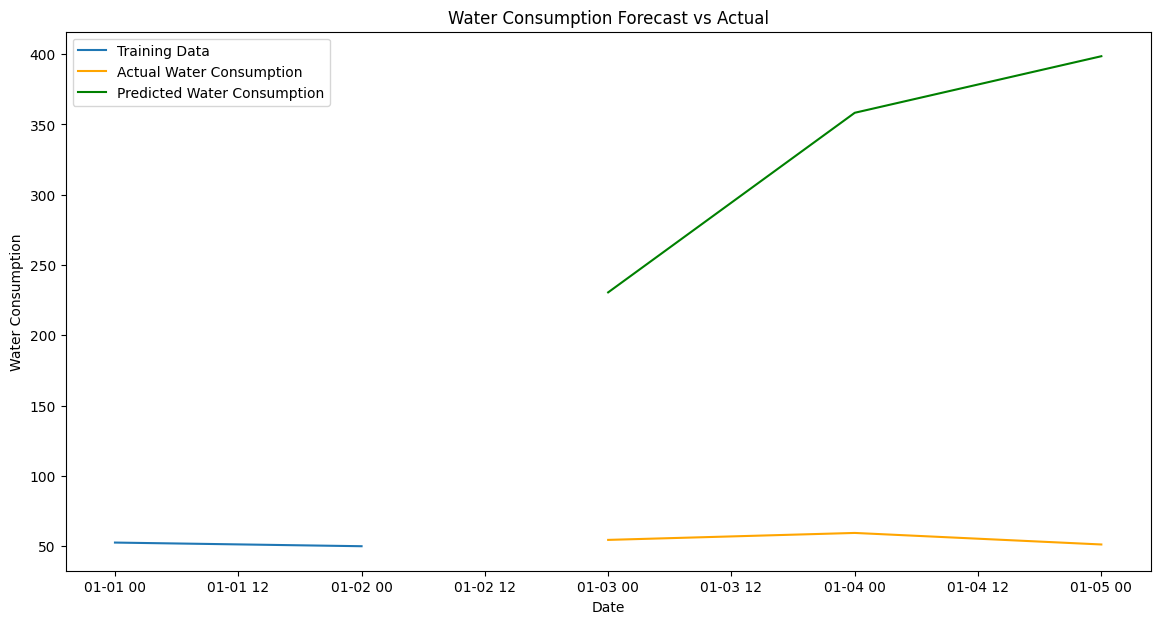

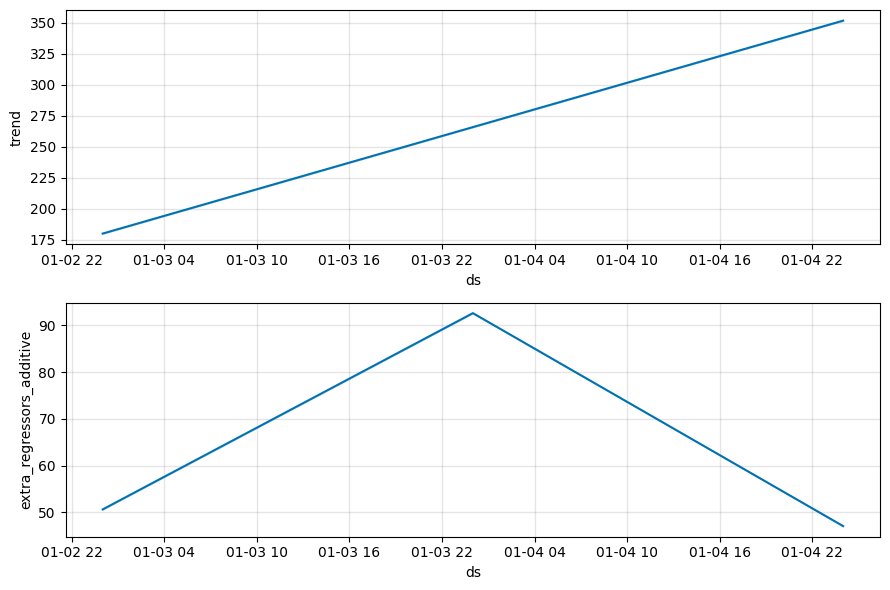

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load data
df = pd.read_csv('Data1.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'])  # Automatically detects the correct format
df = df.rename(columns={'Date': 'ds', 'Value': 'y'})

# Handle missing values in 'y'
df = df.dropna(subset=['y'])

# List of regressor columns
regressors = ['tmax']

# Handle missing values in regressors
df[regressors] = df[regressors].fillna(method='ffill')

# Split data into training and testing sets
# Assuming we use data before '2023-01-01' for training and after for testing
split_date = '2020-01-03'
train = df[df['ds'] < split_date].copy()
test = df[df['ds'] >= split_date].copy()

# Initialize and fit the model
m = Prophet()

# Add regressors to the model
for regressor in regressors:
    m.add_regressor(regressor)

# Fit the model to the training data
m.fit(train)

# Prepare future dataframe for prediction
# For testing, we need to provide the regressor values for the test period
future = test[['ds'] + regressors].copy()


# Make predictions
forecast = m.predict(future)

# Evaluate the model
forecast_evaluation = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds')

mae = mean_absolute_error(forecast_evaluation['y'], forecast_evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_evaluation['y'], forecast_evaluation['yhat']))

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

# Plot the forecast against the actual values
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Actual Water Consumption', color='orange')
plt.plot(forecast_evaluation['ds'], forecast_evaluation['yhat'], label='Predicted Water Consumption', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Water Consumption Forecast vs Actual')
plt.legend()
plt.show()

# Plot the forecast components
m.plot_components(forecast)
plt.show()


## New prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Found custom seasonality named 'weekly', disabling built-in 'weekly' seasonality.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 0.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/hl9lzfom.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/1lcq4vcx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=21670', 'data', 'file=/tmp/tmp767bzkcs/hl9lzfom.json', 'init=/tmp/tmp767bzkcs/1lcq4vcx.json', 'output', 'file=/tmp/tmp767bzkcs/prophet_modelhoht7piz/prophet_model-20250210071138.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:11:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmds

Mean Absolute Error: 435.48
Root Mean Squared Error: 542.02


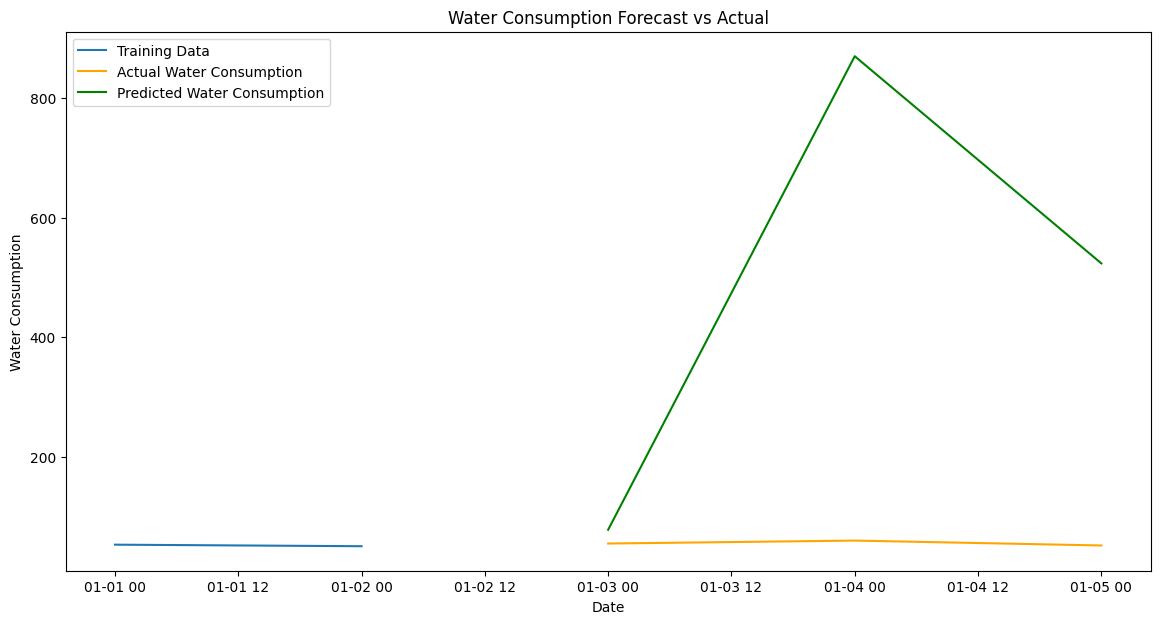

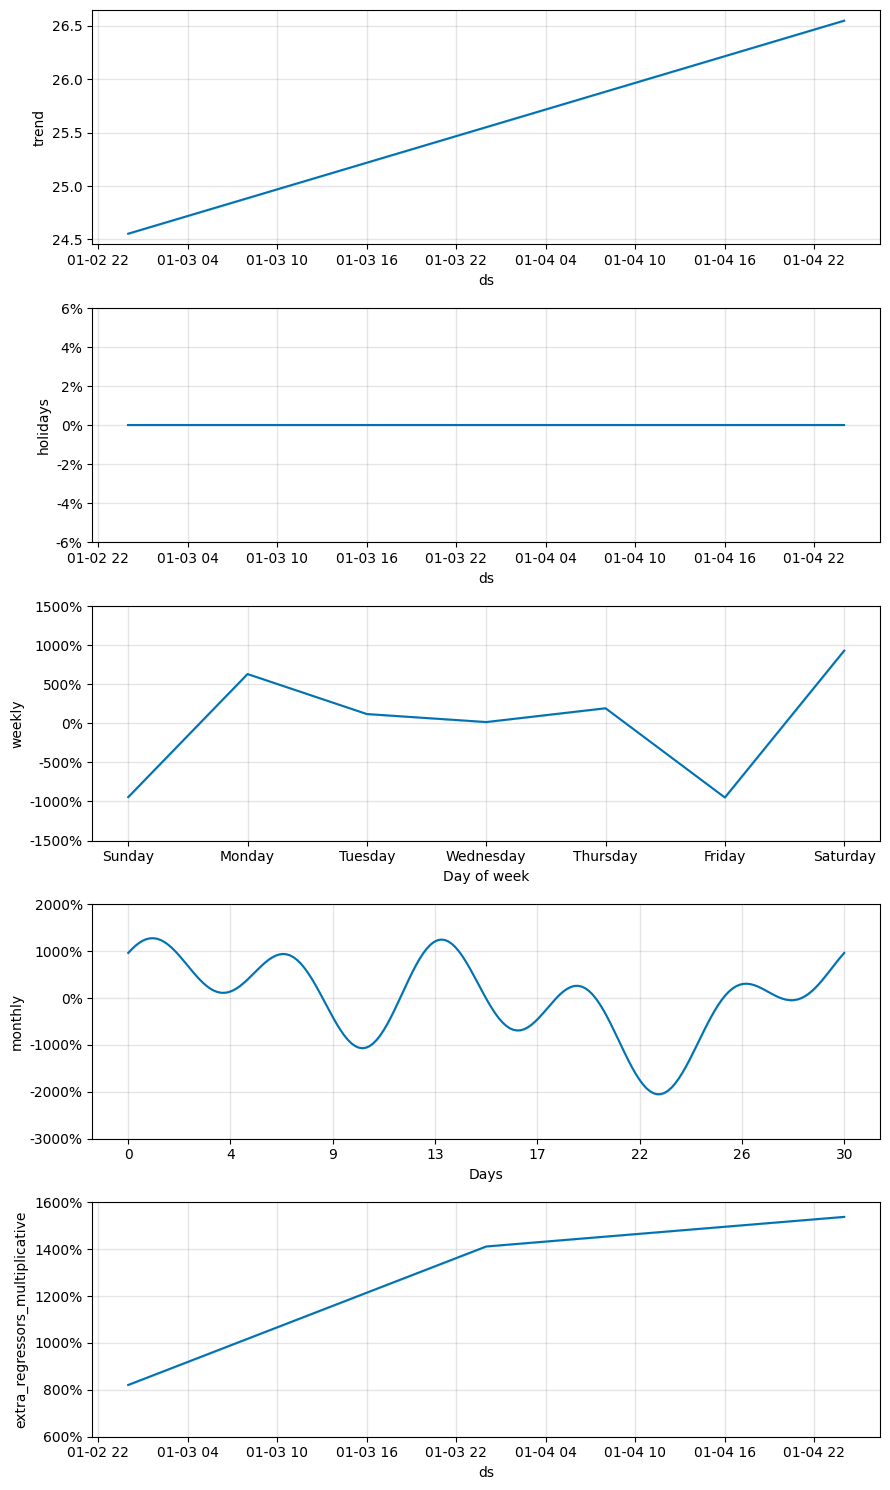

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load data
df = pd.read_csv('Data1.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'])  # Automatically detects the correct format
df = df.rename(columns={'Date': 'ds', 'Value': 'y'})

# Handle missing values in 'y'
df = df.dropna(subset=['y'])

# List of regressors
regressors = ['tmax']

# Handle missing values in regressors
df[regressors] = df[regressors].ffill()

# Additional regressors
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = df['ds'].dt.weekday >= 5

# Update regressors list
regressors.extend(['day_of_week', 'is_weekend'])

# Split data into training and testing sets
split_date = '2020-01-03'
train = df[df['ds'] < split_date].copy()
test = df[df['ds'] >= split_date].copy()

# Initialize the model
m = Prophet(
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)

# Add country holidays
m.add_country_holidays(country_name='ES')

# Add regressors to the model
for regressor in regressors:
    m.add_regressor(regressor)

# Add custom seasonalities
m.add_seasonality(name='weekly', period=7, fourier_order=5)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Fit the model to the training data
m.fit(train)

# Prepare future dataframe for prediction
future = test[['ds'] + regressors].copy()

# Make predictions
forecast = m.predict(future)

# Evaluate the model
forecast_evaluation = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds')

mae = mean_absolute_error(forecast_evaluation['y'], forecast_evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_evaluation['y'], forecast_evaluation['yhat']))
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

# Plot the forecast against the actual values
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Actual Water Consumption', color='orange')
plt.plot(forecast_evaluation['ds'], forecast_evaluation['yhat'], label='Predicted Water Consumption', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Water Consumption Forecast vs Actual')
plt.legend()
plt.show()

# Plot the forecast components
m.plot_components(forecast)
plt.show()


Mrthod 3

Original size: (31, 3)
After dropping NaNs: (31, 3)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Found custom seasonality named 'weekly', disabling built-in 'weekly' seasonality.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/9j8v6tqq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/rxs4yt84.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6107', 'data', 'file=/tmp/tmp767bzkcs/9j8v6tqq.json', 'init=/tmp/tmp767bzkcs/rxs4yt84.json', 'output', 'file=/tmp/tmp767bzkcs/prophet_modelfnke8kai/prophet_model-20250210072014.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:20:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdst

Mean Absolute Error: 6331.47
Root Mean Squared Error: 8740.13
Mean Absolute Percentage Error: 1173.14%


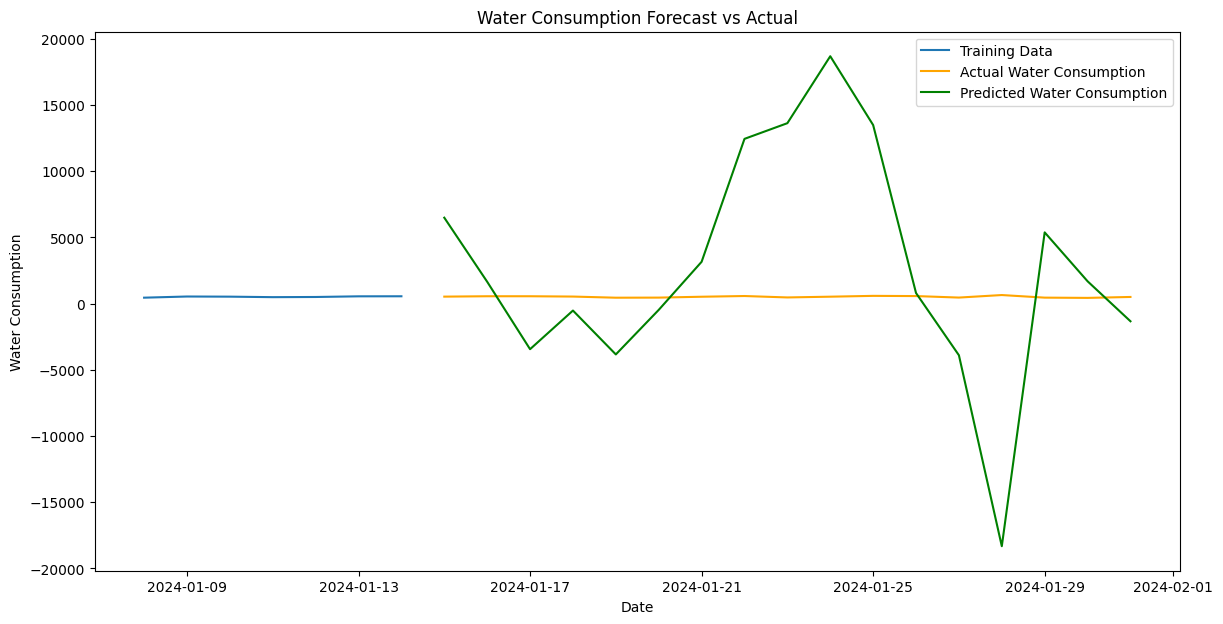

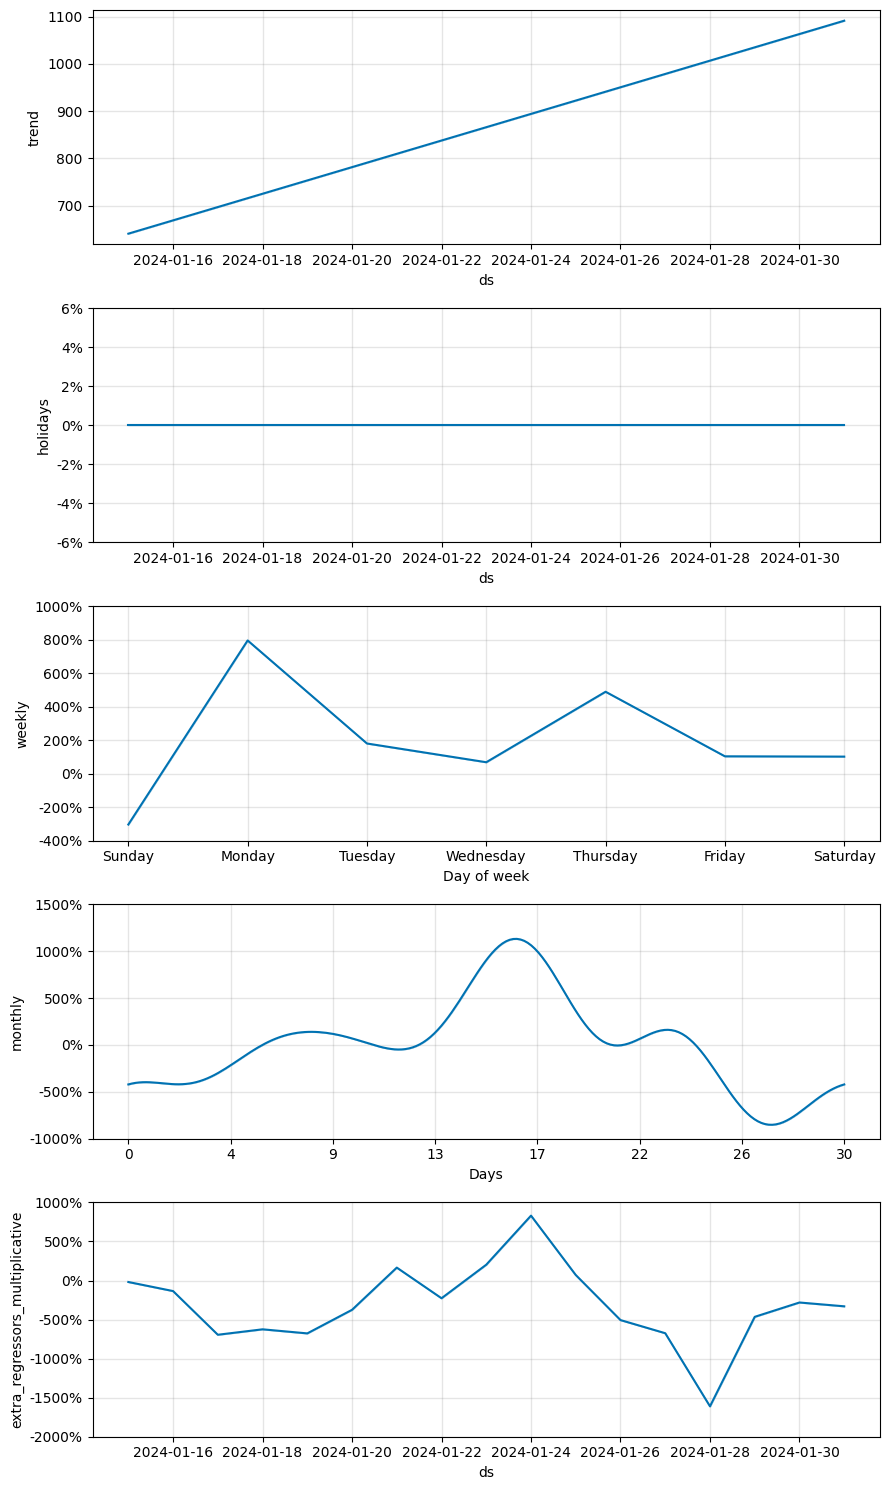

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load data
df = pd.read_csv('Kerala_Household_Water_Usage_Dataset.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'])  # Automatically detects the correct format
df = df.rename(columns={'Date': 'ds', 'Value': 'y'})

# Handle missing values
print(f"Original size: {df.shape}")
df = df.dropna(subset=['y'])
print(f"After dropping NaNs: {df.shape}")  # Should not be (0, N)
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Additional regressors
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# List of regressors
regressors = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Normalize/Scale regressors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[regressors] = scaler.fit_transform(df[regressors])

# Split data into training and testing sets
split_date = '2024-01-15'
train = df[df['ds'] < split_date].copy()
test = df[df['ds'] >= split_date].copy()

# Initialize the model with tuned parameters
m = Prophet(
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15
)

# Add country holidays
m.add_country_holidays(country_name='ES')

# Add regressors to the model
for regressor in regressors:
    m.add_regressor(regressor)

# Add custom seasonalities
m.add_seasonality(name='weekly', period=7, fourier_order=10)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Fit the model to the training data
m.fit(train)

# Prepare future dataframe for prediction
future = test[['ds'] + regressors].copy()

# Make predictions
forecast = m.predict(future)

# Evaluate the model
forecast_evaluation = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds')

# Calculate error metrics
mae = mean_absolute_error(forecast_evaluation['y'], forecast_evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_evaluation['y'], forecast_evaluation['yhat']))

# Calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(forecast_evaluation['y'], forecast_evaluation['yhat'])

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot the forecast against the actual values
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Actual Water Consumption', color='orange')
plt.plot(forecast_evaluation['ds'], forecast_evaluation['yhat'], label='Predicted Water Consumption', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Water Consumption Forecast vs Actual')
plt.legend()
plt.show()

# Plot the forecast components
m.plot_components(forecast)
plt.show()


**Method 1: Prophet with Advanced Feature Engineering
**

In this method, we enhance the Prophet model by adding lagged variables, rolling statistics, and additional regressors to capture more complex patterns.

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Found custom seasonality named 'weekly', disabling built-in 'weekly' seasonality.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/uw0maeki.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp767bzkcs/t5yfmdop.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37657', 'data', 'file=/tmp/tmp767bzkcs/uw0maeki.json', 'init=/tmp/tmp767bzkcs/t5yfmdop.json', 'output', 'file=/tmp/tmp767bzkcs/prophet_modelz562um5s/prophet_model-20250210072115.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:21:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmds

Prophet Model with Advanced Features:
Mean Absolute Error: 6331.47
Root Mean Squared Error: 8740.13
Mean Absolute Percentage Error: 1173.14%


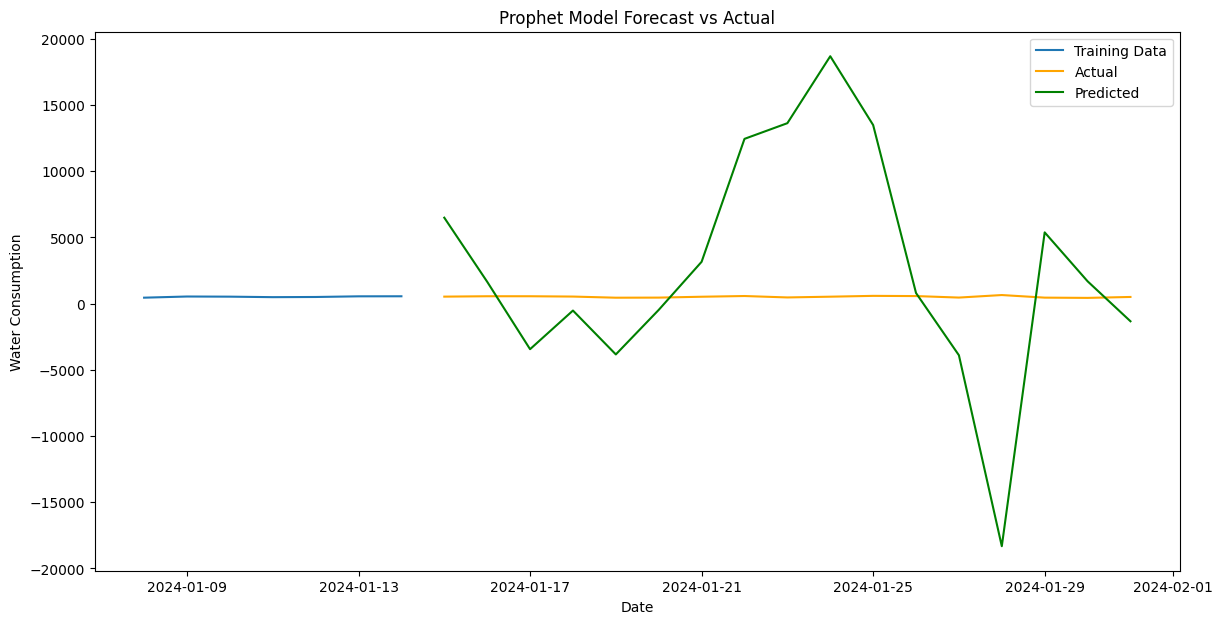

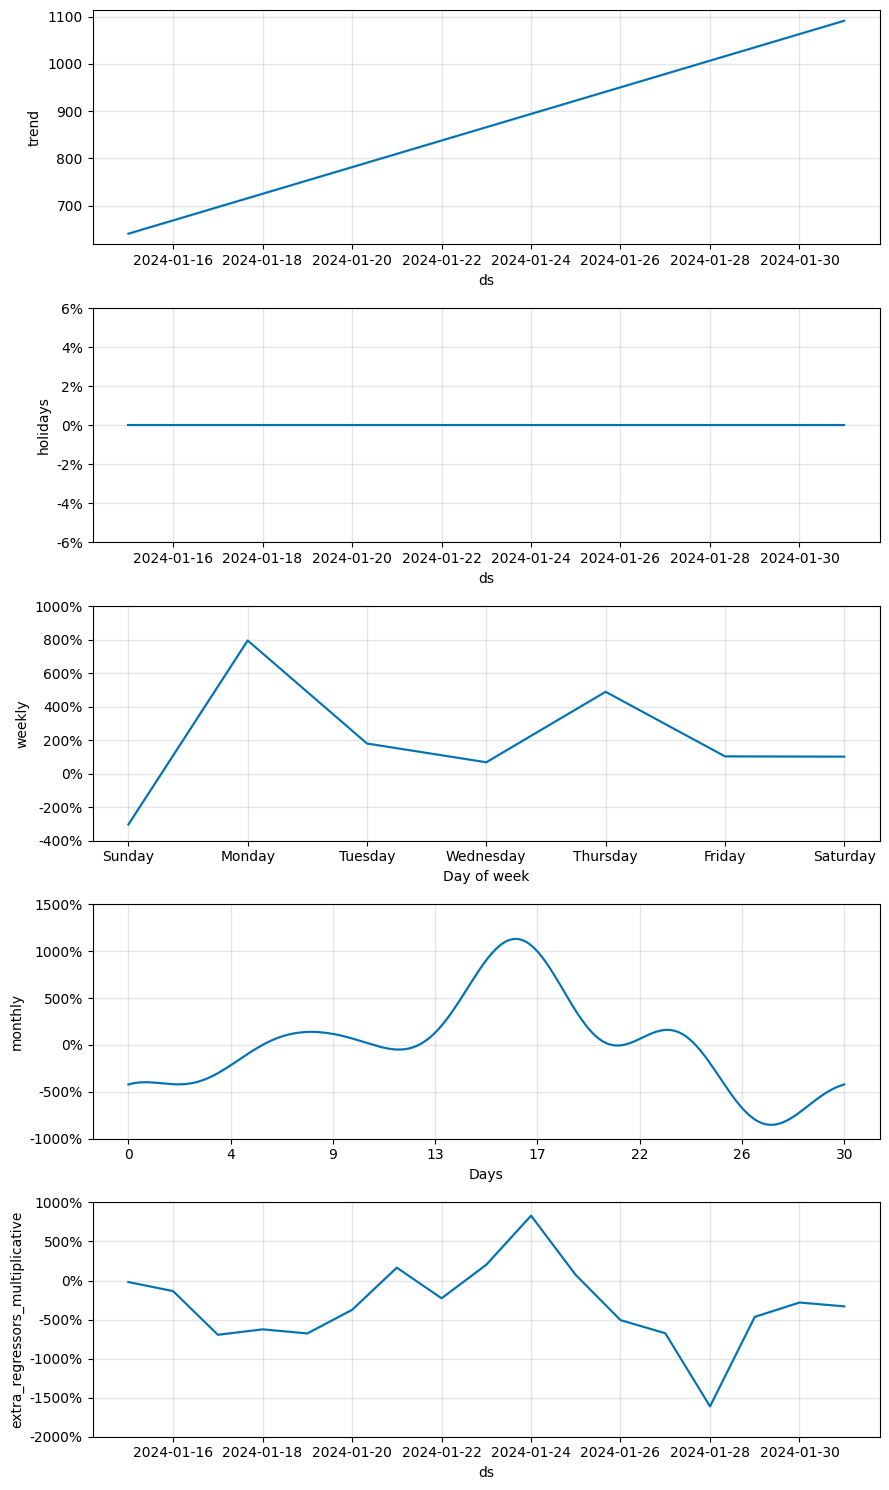

In [ ]:
# Method 1: Prophet with Advanced Feature Engineering

import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv('Kerala_Household_Water_Usage_Dataset.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'])  # Automatically detects the correct format
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Additional regressors
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# List of regressors
regressors = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale regressors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[regressors] = scaler.fit_transform(df[regressors])

# Split data into training and testing sets
split_date = '2024-01-15'
train = df[df['ds'] < split_date]
test = df[df['ds'] >= split_date]

# Initialize and fit the Prophet model
m = Prophet(
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15
)

# Add country holidays
m.add_country_holidays(country_name='ES')

# Add regressors
for regressor in regressors:
    m.add_regressor(regressor)

# Add custom seasonalities
m.add_seasonality(name='weekly', period=7, fourier_order=10)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Fit the model
m.fit(train)

# Prepare future dataframe
future = test[['ds'] + regressors]

# Make predictions
forecast = m.predict(future)

# Evaluate the model
forecast_evaluation = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds')
mae = mean_absolute_error(forecast_evaluation['y'], forecast_evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_evaluation['y'], forecast_evaluation['yhat']))

# Calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)  # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(forecast_evaluation['y'], forecast_evaluation['yhat'])

print('Prophet Model with Advanced Features:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot the forecast
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Actual', color='orange')
plt.plot(forecast_evaluation['ds'], forecast_evaluation['yhat'], label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Prophet Model Forecast vs Actual')
plt.legend()
plt.show()

# Plot forecast components
m.plot_components(forecast)
plt.show()


# Method 2: XGBoost with Hyperparameter Tuning


In [ ]:
!pip install --upgrade xgboost scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.0 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.3
    Uninstalling xgboost-2.1.3:
      Successfully uninstalled xgboost-2.1.3


Here, we use XGBoost with hyperparameter tuning to improve the model's performance.




**XGBoost with Hyperparameter Tuning is a powerful and flexible tool that can be effectively adapted for time series forecasting. While it is not inherently designed for time series data, through meticulous feature engineering, proper data splitting, and hyperparameter optimization, XGBoost can capture complex patterns and deliver high-accuracy forecasts. However, it's essential to balance its advantages with considerations like potential overfitting and the need for extensive feature preparation. Depending on the specific requirements and characteristics of your time series data, XGBoost can be an excellent addition to your forecasting toolkit, often complementing traditional time series models to enhance overall predictive performance.**

In [ ]:
# Method 2: XGBoost with Hyperparameter Tuning

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Kerala_Household_Water_Usage_Dataset.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'])  # Automatically detects the correct format
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]
target = 'y'

# Scale features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Split data
split_date = '2024-01-15'
train = df[df['ds'] < split_date]
test = df[df['ds'] >= split_date]
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# Hyperparameter tuning
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.005, 0.01, 0.05],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2],
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_model = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, y_pred)

print('XGBoost Model with Hyperparameter Tuning:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], y_train, label='Training Data')
plt.plot(test['ds'], y_test, label='Actual', color='orange')
plt.plot(test['ds'], y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('XGBoost Forecast vs Actual')
plt.legend()
plt.show()


AttributeError: 'super' object has no attribute '__sklearn_tags__'

# Method 3: LightGBM Model

This method utilizes LightGBM, another gradient boosting framework, to model the water consumption data.

In [ ]:
# Method 3: LightGBM Model

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Data1.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]
target = 'y'

# Scale features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Split data
split_date = '2023-01-01'
train = df[df['ds'] < split_date]
test = df[df['ds'] >= split_date]
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# Prepare datasets for LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Set parameters
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

# Train model
lgbm_model = lgb.train(
    params,
    train_data,
    num_boost_round=5000,
    valid_sets=[train_data, valid_data],
    early_stopping_rounds=100,
    verbose_eval=100
)

# Predict
y_pred = lgbm_model.predict(X_test, num_iteration=lgbm_model.best_iteration)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print('LightGBM Model Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], y_train, label='Training Data')
plt.plot(test['ds'], y_test, label='Actual', color='orange')
plt.plot(test['ds'], y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('LightGBM Forecast vs Actual')
plt.legend()
plt.show()


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

# Method 4: Stacking Ensemble



This method combines multiple models (XGBoost and LightGBM) using a stacking ensemble to improve performance.




In [ ]:
!pip install dask[dataframe]

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 7.5 MB/s eta 0:00:00


In [ ]:
# Method 4: Stacking Ensemble

import pandas as pd
import numpy as np
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Kerala_Household_Water_Usage_Dataset.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'])  # Automatically detects the correct format
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]
target = 'y'

# Scale features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Split data
split_date = '2023-01-01'
train = df[df['ds'] < split_date]
test = df[df['ds'] >= split_date]
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# Define base models
estimators = [
    ('xgb', xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=6, random_state=42)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, num_leaves=31, random_state=42))
]

# Stacking regressor
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)

# Fit the model
stacking_model.fit(X_train, y_train)

# Predict
y_pred = stacking_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print('Stacking Ensemble Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], y_train, label='Training Data')
plt.plot(test['ds'], y_test, label='Actual', color='orange')
plt.plot(test['ds'], y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Stacking Ensemble Forecast vs Actual')
plt.legend()
plt.show()


AttributeError: 'super' object has no attribute '__sklearn_tags__'

# Method 5: LSTM Neural Network

In this method, we implement an LSTM neural network to capture temporal dependencies in the data.

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 350ms/step - loss: 0.6042 - val_loss: 0.2321
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2860 - val_loss: 0.0636
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0591 - val_loss: 0.0333
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0417 - val_loss: 0.0587
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0416 - val_loss: 0.0239
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0232 - val_loss: 0.0206
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0273 - val_loss: 0.0214
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0244 - val_loss: 0.0204
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0241 - val_loss: 0.0211
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0222 - val_loss: 0.0233
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0227 - val_loss: 0.0233
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0220 - val_loss: 0.0213
Epoch 13/50

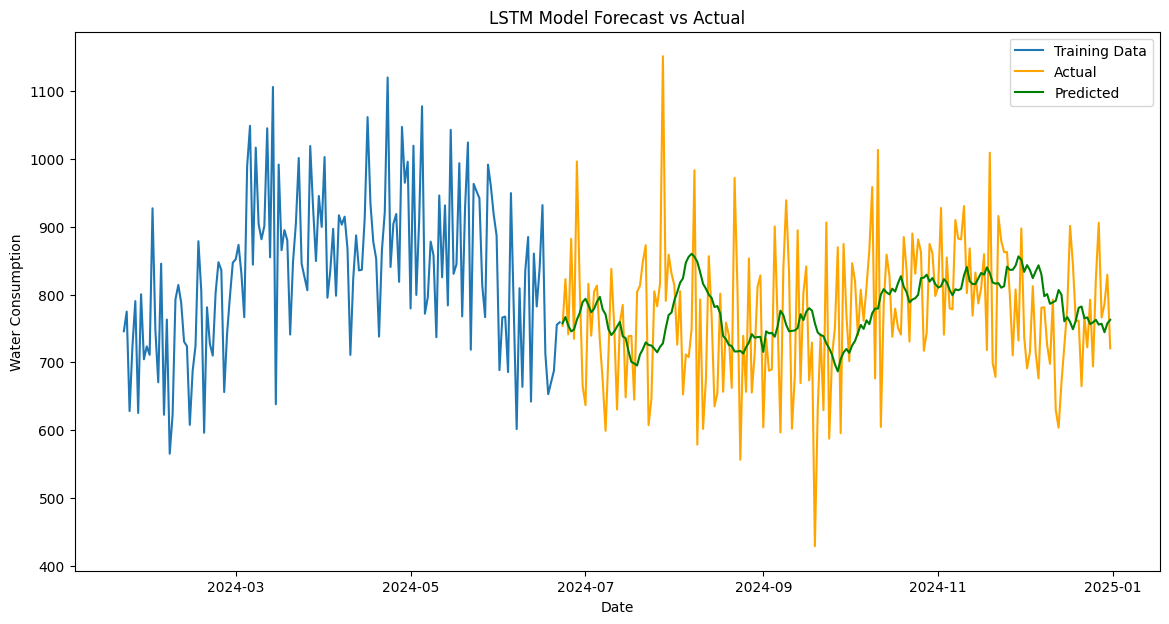

In [ ]:
# Updated Method 5: LSTM Neural Network

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Kerala_Household_Water_Consumption.csv')


df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target
scaled_data = np.hstack((scaled_features, scaled_target))

# Create sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except the last (target)
        y.append(data[i, -1])  # The last column (target)
    return np.array(X), np.array(y)

seq_length = 14  # Two weeks
X, y = create_sequences(scaled_data, seq_length)

# Create date array corresponding to y
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split data based on date
split_date = pd.to_datetime('2024-06-23')

train_indices = dates < split_date
test_indices = dates >= split_date

X_train_lstm = X[train_indices]
X_test_lstm = X[test_indices]
y_train_lstm = y[train_indices]
y_test_lstm = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# Build the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

# Predict
y_pred_lstm = model.predict(X_test_lstm)

# Inverse scale the predictions
y_test_inv = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred_lstm).flatten()

# Evaluate
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print('LSTM Model Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('LSTM Model Forecast vs Actual')
plt.legend()
plt.show()


Prophet Model optimize

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6oe_ef2n/lu7mw1gr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6oe_ef2n/kcy__cvh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75927', 'data', 'file=/tmp/tmp6oe_ef2n/lu7mw1gr.json', 'init=/tmp/tmp6oe_ef2n/kcy__cvh.json', 'output', 'file=/tmp/tmp6oe_ef2n/prophet_modelsjwrvrki/prophet_model-20250210075549.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:55:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:55:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Mean Absolute Error: 95.36
Root Mean Squared Error: 120.23


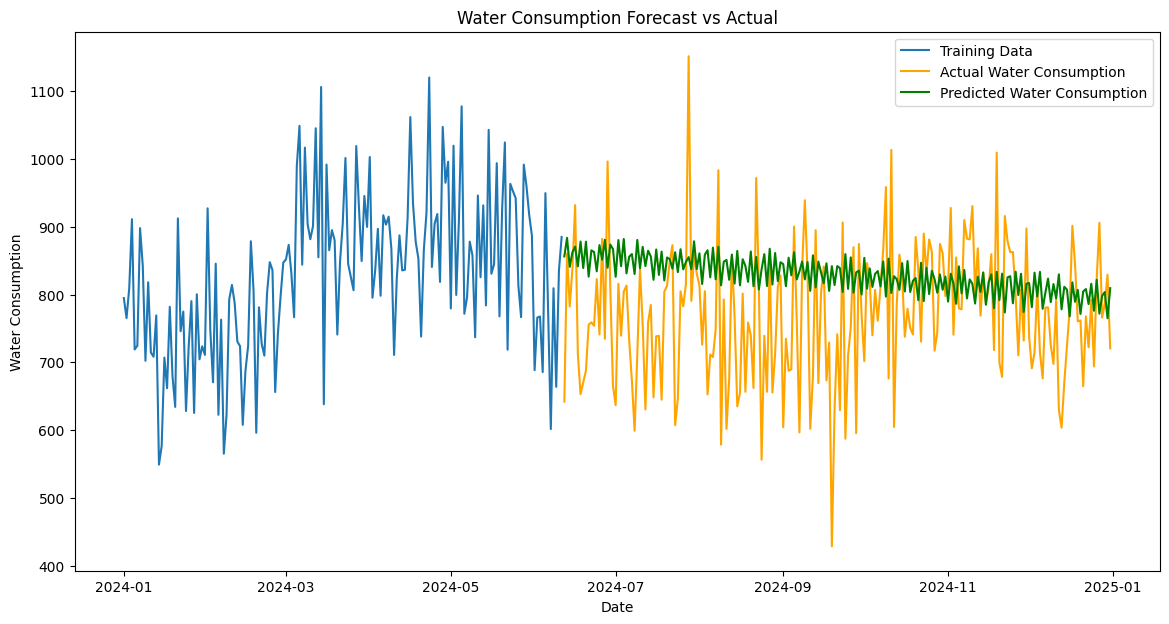

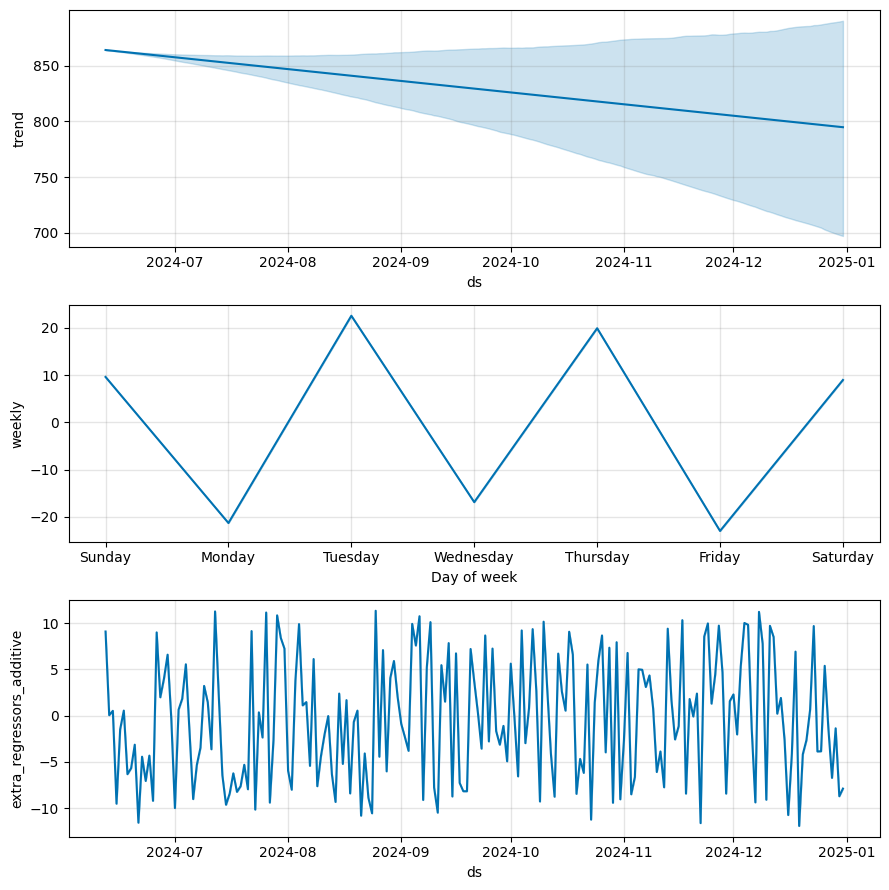

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load data
df = pd.read_csv('Kerala_Household_Water_Consumption.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.rename(columns={'Date': 'ds', 'Value': 'y'})

# Handle missing values in 'y'
df = df.dropna(subset=['y'])

# List of regressor columns
regressors = ['tmax']

# Handle missing values in regressors - Consider interpolation instead of ffill
df[regressors] = df[regressors].interpolate()

# Split data into training and testing sets
split_date = '2024-06-12'
train = df[df['ds'] < split_date].copy()
test = df[df['ds'] >= split_date].copy()

# Initialize and fit the model
# Experiment with different changepoint_prior_scale, seasonality_prior_scale
m = Prophet(changepoint_prior_scale=0.05, seasonality_prior_scale=10)

# Add regressors to the model
for regressor in regressors:
    m.add_regressor(regressor)

# Fit the model to the training data
m.fit(train)

# Prepare future dataframe for prediction
future = test[['ds'] + regressors].copy()

# Make predictions
forecast = m.predict(future)

# Evaluate the model
forecast_evaluation = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds')

mae = mean_absolute_error(forecast_evaluation['y'], forecast_evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_evaluation['y'], forecast_evaluation['yhat']))

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

# Plot the forecast against the actual values
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Actual Water Consumption', color='orange')
plt.plot(forecast_evaluation['ds'], forecast_evaluation['yhat'], label='Predicted Water Consumption', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Water Consumption Forecast vs Actual')
plt.legend()
plt.show()

# Plot the forecast components
m.plot_components(forecast)
plt.show()


# Mehran's Model 1

In [ ]:
! pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.4 MB/s eta 0:00:00


Reloading Tuner from my_dir/lstm_hyperband/tuner0.json
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - loss: 0.0329 - val_loss: 0.0234
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0238 - val_loss: 0.0207
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0197 - val_loss: 0.0222
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0208 - val_loss: 0.0201
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0209 - val_loss: 0.0200
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0205 - val_loss: 0.0208
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0198 - val_loss: 0.0198
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0206 - val_loss: 0.0197
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0186 - val_loss: 0.0202
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0210 - val_loss: 0.0202
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0191 - val_loss: 0.0196
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0215 - val_loss: 0.0198
Epoch 13/50

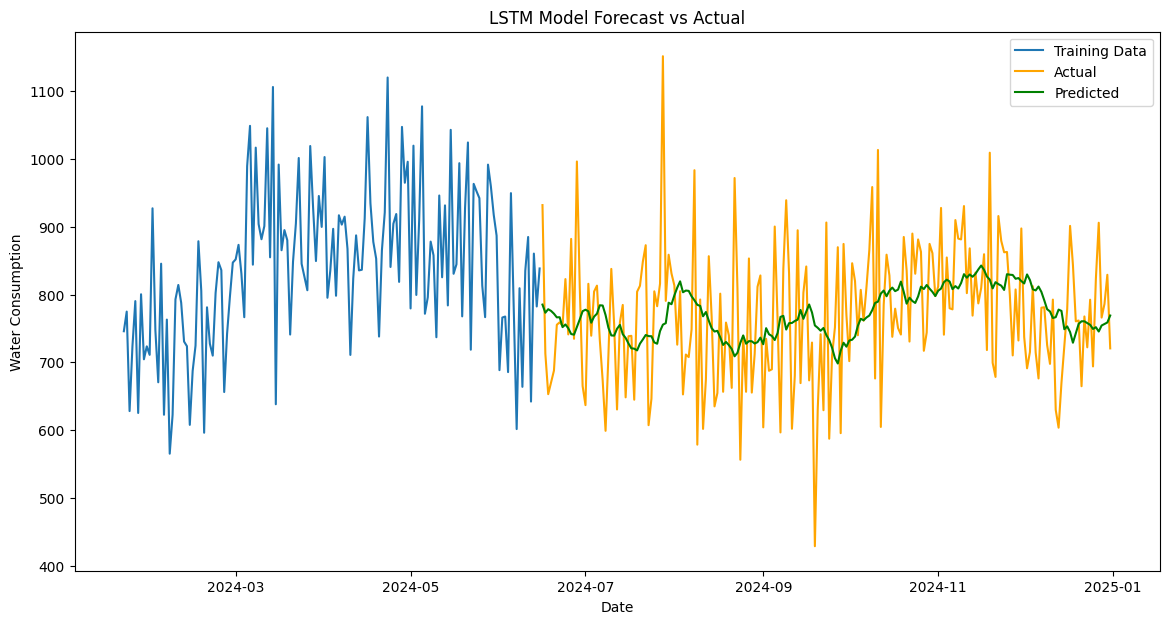

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from kerastuner.tuners import Hyperband

# Load data
df = pd.read_csv('Kerala_Household_Water_Consumption.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target
scaled_data = np.hstack((scaled_features, scaled_target))

# Create sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except the last (target)
        y.append(data[i, -1])  # The last column (target)
    return np.array(X), np.array(y)

seq_length = 14  # Two weeks
X, y = create_sequences(scaled_data, seq_length)

# Create date array corresponding to y
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split data based on date
split_date = pd.to_datetime('2024-06-16')

train_indices = dates < split_date
test_indices = dates >= split_date

X_train_lstm = X[train_indices]
X_test_lstm = X[test_indices]
y_train_lstm = y[train_indices]
y_test_lstm = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# Define the model builder function for Keras Tuner
def build_model(hp):
    model = tf.keras.Sequential()
    # Tune the number of units in the LSTM layer
    lstm_units = hp.Choice('units', values=[32, 64, 128])
    model.add(tf.keras.layers.LSTM(lstm_units, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
    model.add(tf.keras.layers.Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mse')
    return model

# Initialize the Keras Tuner
tuner = Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    directory='my_dir',
    project_name='lstm_hyperband'
)

# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Search for the best model
tuner.search(X_train_lstm, y_train_lstm, epochs=50, validation_data=(X_test_lstm, y_test_lstm), callbacks=[early_stopping], verbose=1)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Train the best model further if needed
history = best_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stopping],
    verbose=1
)

# Predict
y_pred_lstm = best_model.predict(X_test_lstm)

# Inverse scale the predictions
y_test_inv = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred_lstm).flatten()

# Evaluate
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print('LSTM Model Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('LSTM Model Forecast vs Actual')
plt.legend()
plt.show()

# Mehran's Model 2

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 987ms/step - loss: 0.2547 - val_loss: 0.1100 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1224 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0347 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0473 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0327 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0334 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0283 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0342 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0229 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
LSTM Model with Additional Layers and GRU Results:
Mean Absolute Error: 79.50
Root Mean Squared Error: 100.20
Mean Absolute Percentage Error: 10.65%
R² Score: -0.01


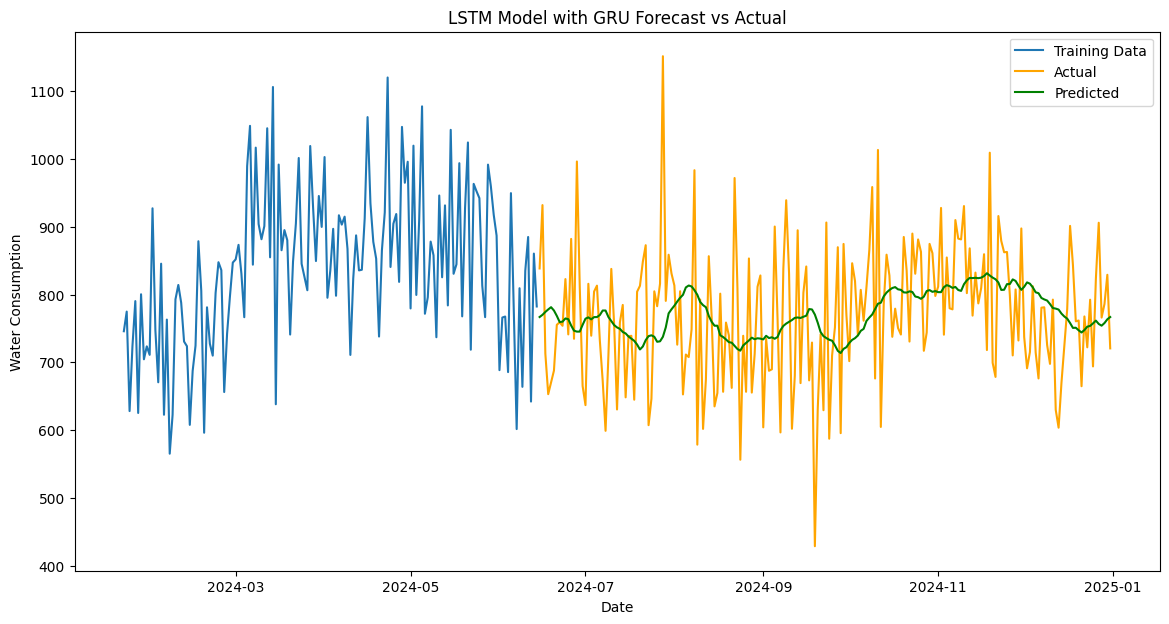

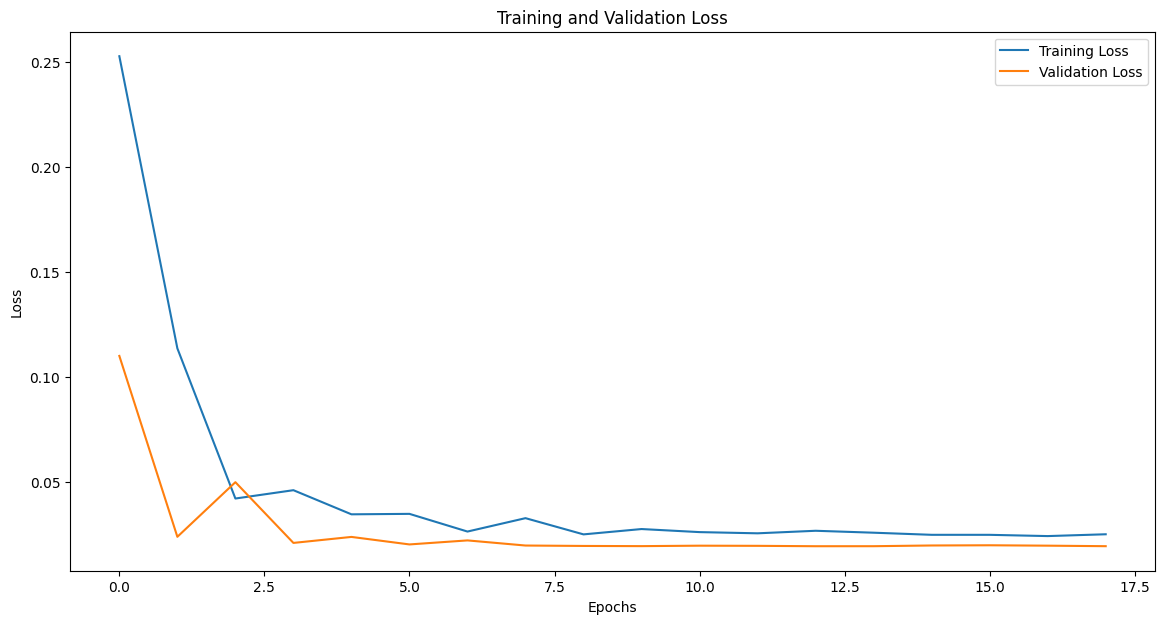

In [ ]:
# Updated Method 5: LSTM Neural Network with additional layers and GRU

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Kerala_Household_Water_Consumption.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target
scaled_data = np.hstack((scaled_features, scaled_target))

# Create sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except the last (target)
        y.append(data[i, -1])  # The last column (target)
    return np.array(X), np.array(y)

seq_length = 14  # Two weeks
X, y = create_sequences(scaled_data, seq_length)

# Create date array corresponding to y
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split data based on date
split_date = pd.to_datetime('2024-06-15')

train_indices = dates < split_date
test_indices = dates >= split_date

X_train_lstm = X[train_indices]
X_test_lstm = X[test_indices]
y_train_lstm = y[train_indices]
y_test_lstm = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# Build the LSTM model with additional layers and GRU
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    tf.keras.layers.GRU(32, activation='relu', return_sequences=False),  # Added GRU layer
    tf.keras.layers.Dense(64, activation='relu'),  # Added Dense layer
    tf.keras.layers.Dropout(0.2),  # Dropout to prevent overfitting
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model with early stopping and learning rate reduction
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# Predict
y_pred_lstm = model.predict(X_test_lstm)

# Inverse scale the predictions
y_test_inv = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred_lstm).flatten()

# Evaluate
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print('LSTM Model with Additional Layers and GRU Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')
print(f'R² Score: {r2:.2f}')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('LSTM Model with GRU Forecast vs Actual')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Mehran's Model 3 LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 534ms/step - loss: 0.0731 - val_loss: 0.0294
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0364 - val_loss: 0.0152
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0232 - val_loss: 0.0184
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0247 - val_loss: 0.0170
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0227 - val_loss: 0.0149
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0220 - val_loss: 0.0150
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0227 - val_loss: 0.0151
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0228 - val_loss: 0.0148
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0223 - val_loss: 0.0146
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0219 - val_loss: 0.0147
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0216 - val_loss: 0.0146
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0215 - val_loss: 0.0145


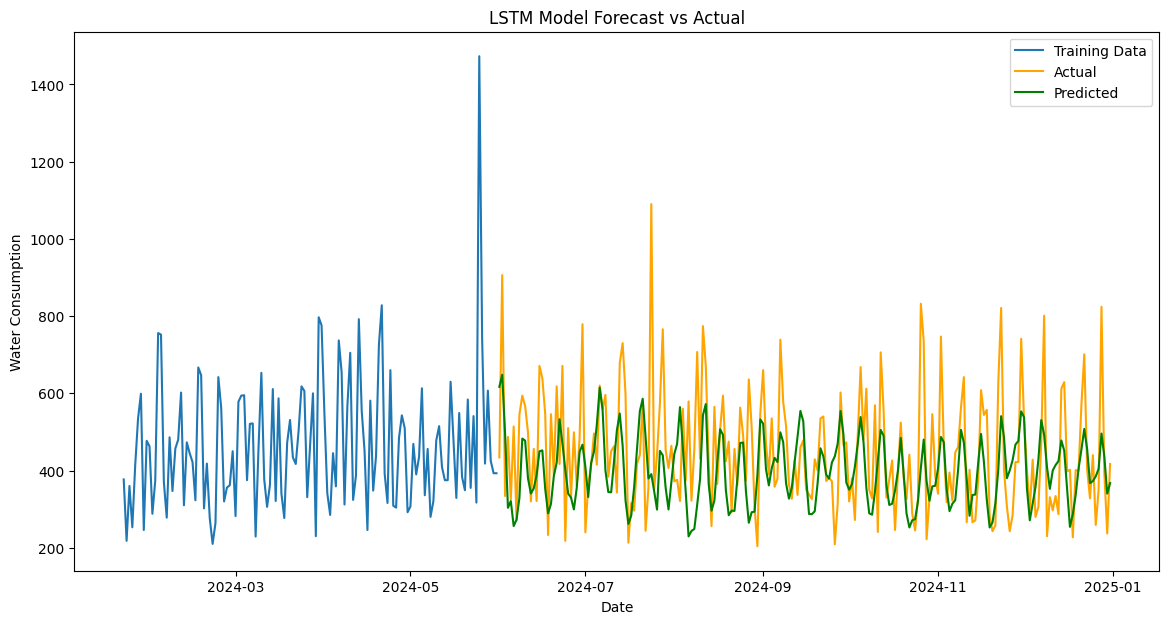

In [23]:
# Updated Method 5: LSTM Neural Network

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, fbeta_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Water_Consumption_Dataset.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target
scaled_data = np.hstack((scaled_features, scaled_target))

# Create sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except the last (target)
        y.append(data[i, -1])  # The last column (target)
    return np.array(X), np.array(y)

seq_length = 14  # Two weeks
X, y = create_sequences(scaled_data, seq_length)

# Create date array corresponding to y
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split data based on date
split_date = pd.to_datetime('2024-06-01')

train_indices = dates < split_date
test_indices = dates >= split_date

X_train_lstm = X[train_indices]
X_test_lstm = X[test_indices]
y_train_lstm = y[train_indices]
y_test_lstm = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# Build the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

# Predict
y_pred_lstm = model.predict(X_test_lstm)

# Inverse scale the predictions
y_test_inv = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred_lstm).flatten()

# Evaluate
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

# For F2 Score, we need to binarize the target. We'll classify it as '1' if the prediction is above the median.
y_test_bin = np.where(y_test_inv > np.median(y_test_inv), 1, 0)
y_pred_bin = np.where(y_pred_inv > np.median(y_pred_inv), 1, 0)

# Calculate F2 Score
f2_score = fbeta_score(y_test_bin, y_pred_bin, beta=2)

print('LSTM Model Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')
print(f'F2 Score: {f2_score:.2f}')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('LSTM Model Forecast vs Actual')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0200

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0190 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0131 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0126

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0126 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0124 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0120 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0121 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0118 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 8/100
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0118 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 9/100
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0115

...

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0096 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 30/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0096 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 31/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0093 - val_loss: 0.0065 - learning_rate: 2.5000e-04
Epoch 32/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0096 - val_loss: 0.0066 - learning_rate: 2.5000e-04
Epoch 33/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0102

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0101 - val_loss: 0.0064 - learning_rate: 2.5000e-04
Epoch 34/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0095 - val_loss: 0.0064 - learning_rate: 2.5000e-04
Epoch 35/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - val_loss: 0.0065 - learning_rate: 2.5000e-04
Epoch 36/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0098

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0098 - val_loss: 0.0063 - learning_rate: 1.2500e-04
Epoch 37/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0095 - val_loss: 0.0064 - learning_rate: 1.2500e-04
Epoch 38/100
16/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0091

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0093 - val_loss: 0.0063 - learning_rate: 1.2500e-04
Epoch 39/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0093 - val_loss: 0.0063 - learning_rate: 1.2500e-04
Epoch 40/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0063 - learning_rate: 1.2500e-04
Epoch 41/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0094 - val_loss: 0.0063 - learning_rate: 1.2500e-04
Epoch 42/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0092 - val_loss: 0.0063 - learning_rate: 6.2500e-05
Epoch 43/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0095 - val_loss: 0.0063 - learning_rate: 6.2500e-05
Epoch 44/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0093 - val_loss: 0.0063 - learning_rate: 6.2500e-05
Epoch 45/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0063 - learning_rate: 6.2500e-05
Epoch 46/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0094 - val_loss: 0.0063 - learning_rate: 6.2500e-05
Epoch 47/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0063 - lear

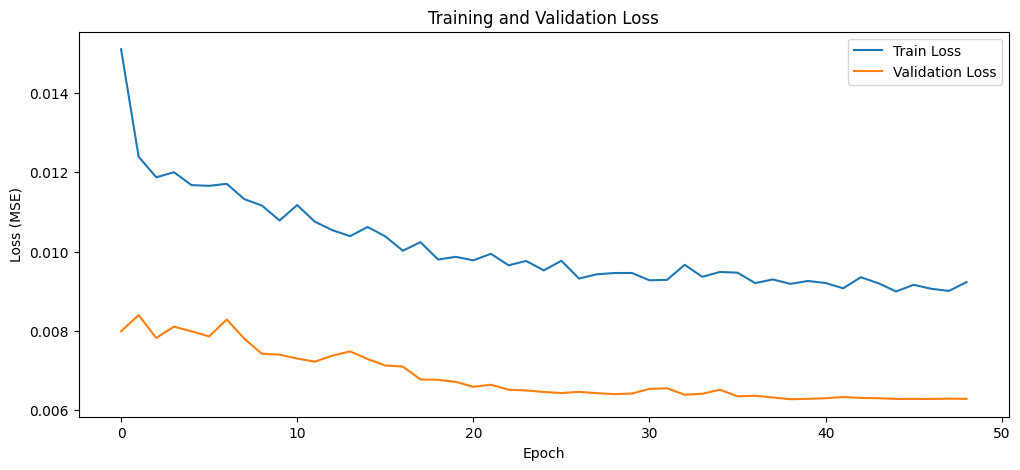

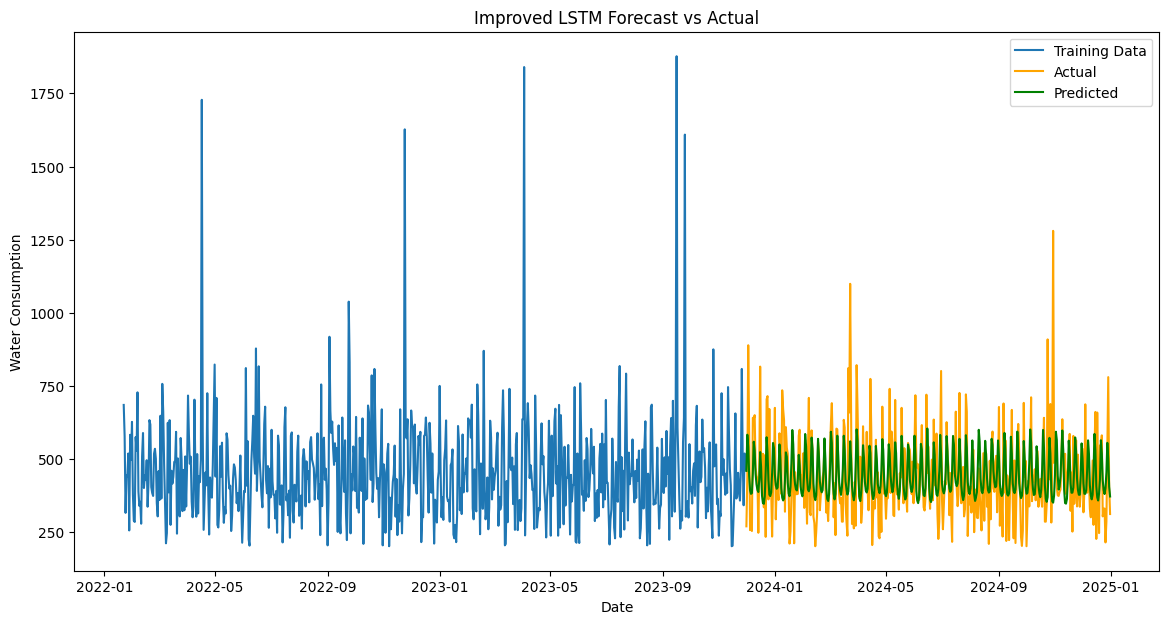

In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, fbeta_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# =======================
# 1. Reproducibility Setup
# =======================
np.random.seed(42)
tf.random.set_seed(42)

# =======================
# 2. Data Loading & Preprocessing
# =======================
# Load data
df = pd.read_csv('3-Year_Water_Consumption_Dataset.csv')

# Convert date to datetime and rename columns for consistency
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values resulting from shifting/rolling operations
df = df.dropna()

# Define features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale features and target separately using MinMaxScaler
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target into one array for sequence creation
scaled_data = np.hstack((scaled_features, scaled_target))

# Function to create sequences for LSTM input
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except the target
        y.append(data[i, -1])                 # Target value
    return np.array(X), np.array(y)

seq_length = 14  # Use two weeks of data as input
X, y = create_sequences(scaled_data, seq_length)

# Create corresponding dates for the target values
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split data based on a date (you can adjust this date as needed)
split_date = pd.to_datetime('2023-12-01')
train_indices = dates < split_date
test_indices = dates >= split_date

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# =======================
# 3. Build the Improved LSTM Model
# =======================
model = tf.keras.Sequential([
    # First LSTM layer with return_sequences=True to feed into another LSTM layer
    tf.keras.layers.LSTM(64, return_sequences=True,
                         input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dropout(0.2),
    # Second LSTM layer
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    # Additional dense layer to refine the learned features
    tf.keras.layers.Dense(16, activation='relu'),
    # Final output layer
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# =======================
# 4. Define Callbacks for Training
# =======================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_lstm_model.h5', monitor='val_loss', save_best_only=True)
]

# =======================
# 5. Train the Model
# =======================
history = model.fit(
    X_train, y_train,
    epochs=100,            # Increased maximum epochs (early stopping will prevent overfitting)
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# =======================
# 6. Predictions & Evaluation
# =======================
# Generate predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform to get predictions back to original scale
y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred_scaled).flatten()

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

# For F2 Score, binarize the target values based on the median
y_test_bin = np.where(y_test_inv > np.median(y_test_inv), 1, 0)
y_pred_bin = np.where(y_pred_inv > np.median(y_pred_inv), 1, 0)
f2_score = fbeta_score(y_test_bin, y_pred_bin, beta=2)

print('Improved LSTM Model Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')
print(f'F2 Score: {f2_score:.2f}')

# =======================
# 7. Plotting Results
# =======================
# Plot training and validation loss over epochs
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot the actual vs. predicted water consumption
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Improved LSTM Forecast vs Actual')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0577

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 549ms/step - loss: 0.0556 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - loss: 0.0230 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0217 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0201 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - loss: 0.0203 - val_loss: 0.0361 - learning_rate: 5.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0175 - val_loss: 0.0324 - learning_rate: 5.0000e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step
Improved LSTM-GRU Model Results:
Mean Absolute Error: 158.17
Root Mean Squared Error: 207.88
Mean Absolute Percentage Error: 30.54%
R² Score: -0.84


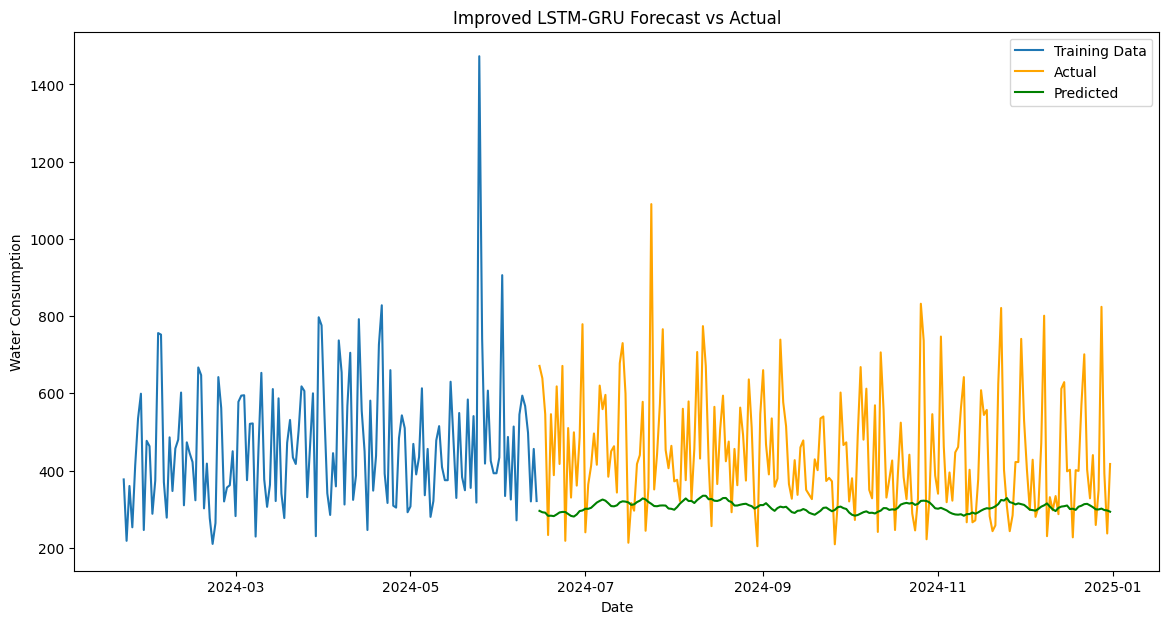

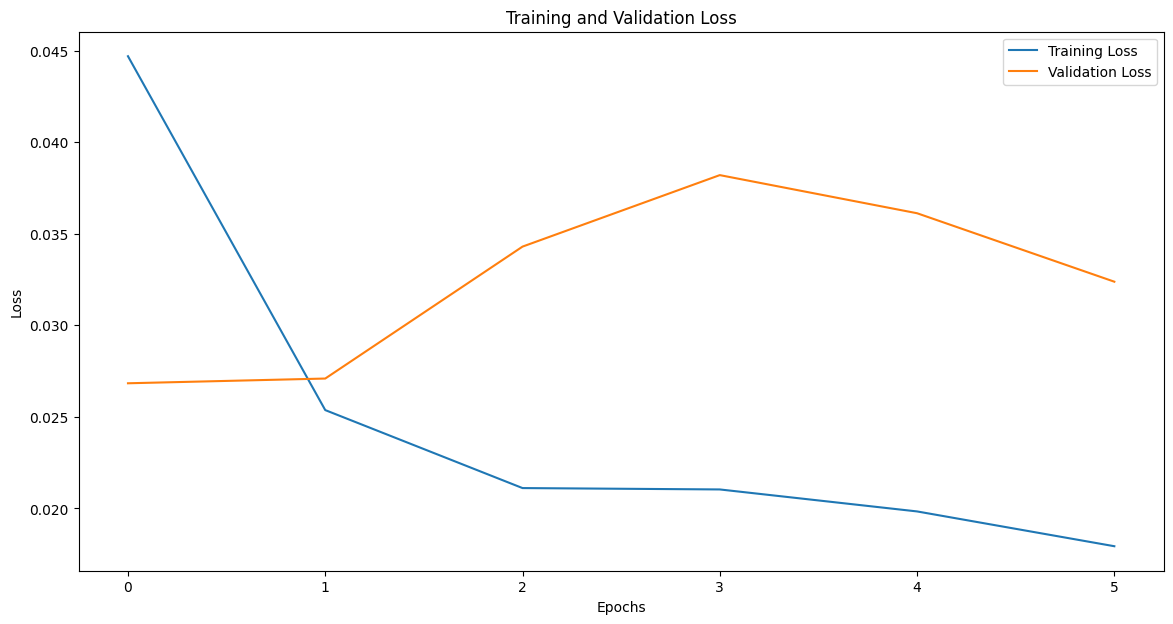

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Water_Consumption_Dataset.csv')

# Prepare data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values resulting from shifting/rolling
df = df.dropna()

# Features and target
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target
scaled_data = np.hstack((scaled_features, scaled_target))

# Create sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except the last (target)
        y.append(data[i, -1])  # The last column (target)
    return np.array(X), np.array(y)

seq_length = 14  # Two weeks
X, y = create_sequences(scaled_data, seq_length)

# Create date array corresponding to y
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split data based on date
split_date = pd.to_datetime('2024-06-15')
train_indices = dates < split_date
test_indices = dates >= split_date

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# Build the improved model
model = tf.keras.Sequential([
    # 1D CNN layer to capture local patterns in the sequences
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu',
                           input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.BatchNormalization(),

    # First Bidirectional LSTM layer with dropout and recurrent dropout
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
    ),

    # Second Bidirectional GRU layer with dropout and recurrent dropout
    tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
    ),

    # Global pooling to reduce the output over time dimension
    tf.keras.layers.GlobalAveragePooling1D(),

    # Dense layers for further nonlinear processing
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

# Compile the model with a lower learning rate for fine-tuning
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# Set up callbacks: early stopping, learning rate reduction, and model checkpointing
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, lr_scheduler, checkpoint],
    verbose=1
)

# Predict on test set
y_pred = model.predict(X_test)

# Inverse scale the predictions and actual values
y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred).flatten()

# Evaluate predictions
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print('Improved LSTM-GRU Model Results:')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')
print(f'R² Score: {r2:.2f}')

# Plot predictions vs. actual values
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Improved LSTM-GRU Forecast vs Actual')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Epoch 1/100
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - classification_accuracy: 0.8795 - classification_loss: 0.4997 - loss: 0.5115 - regression_loss: 0.0118 - regression_mae: 0.1150

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - classification_accuracy: 0.8825 - classification_loss: 0.4816 - loss: 0.4938 - regression_loss: 0.0122 - regression_mae: 0.1173 - val_classification_accuracy: 0.9344 - val_classification_loss: 0.2595 - val_loss: 0.2551 - val_regression_loss: 0.0027 - val_regression_mae: 0.0613 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - classification_accuracy: 0.8979 - classification_loss: 0.3365 - loss: 0.3447 - regression_loss: 0.0083 - regression_mae: 0.0957

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - classification_accuracy: 0.8980 - classification_loss: 0.3363 - loss: 0.3445 - regression_loss: 0.0082 - regression_mae: 0.0957 - val_classification_accuracy: 0.9344 - val_classification_loss: 0.2512 - val_loss: 0.2456 - val_regression_loss: 0.0027 - val_regression_mae: 0.0597 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - classification_accuracy: 0.8980 - classification_loss: 0.3341 - loss: 0.3419 - regression_loss: 0.0079 - regression_mae: 0.0907 - val_classification_accuracy: 0.9344 - val_classification_loss: 0.2539 - val_loss: 0.2491 - val_regression_loss: 0.0029 - val_regression_mae: 0.0635 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - classification_accuracy: 0.8980 - classification_loss: 0.3430 - loss: 0.3499 - regression_loss: 0.0069 - regression_mae: 0.0855 - val_classification_accuracy: 0.9344 - val_classification_loss: 0.2552 - val_loss: 0.2503 - val_regression_loss: 0.00

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


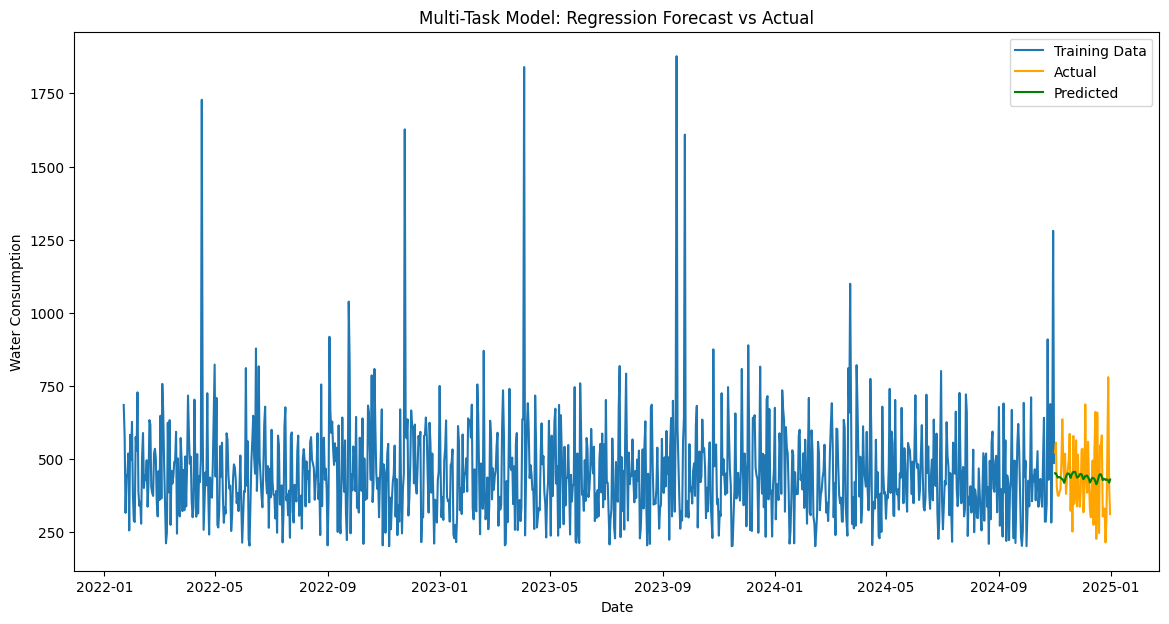

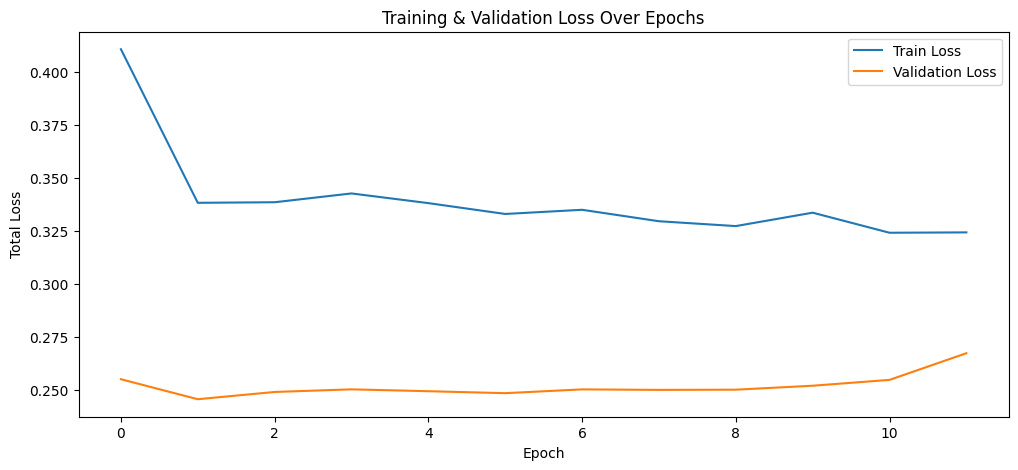

In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, fbeta_score, classification_report
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ===============================
# 1. Reproducibility & Imports
# ===============================
np.random.seed(42)
tf.random.set_seed(42)

# ===============================
# 2. Data Loading & Preprocessing
# ===============================
# Load the dataset
df = pd.read_csv('3-Year_Water_Consumption_Dataset.csv')

# Convert date to datetime and rename columns
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.rename(columns={'Date': 'ds', 'Value': 'y'}, inplace=True)

# Handle missing values
df = df.dropna(subset=['y'])
df['tmax'] = df['tmax'].ffill()

# Create lag features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['tmax_lag1'] = df['tmax'].shift(1)
df['tmax_lag7'] = df['tmax'].shift(7)

# Create rolling mean features
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()
df['tmax_roll_mean_7'] = df['tmax'].rolling(window=7).mean()

# Additional time-based features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)

# Drop rows with NaN values from lag/rolling operations
df = df.dropna()

# Define feature columns
features = [
    'tmax', 'tmax_lag1', 'tmax_lag7', 'tmax_roll_mean_7',
    'y_lag1', 'y_lag7', 'y_roll_mean_7',
    'day_of_week', 'is_weekend'
]

# ===============================
# 3. Scaling & Sequence Creation
# ===============================
# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])

# Combine scaled features and target for sequence generation
scaled_data = np.hstack((scaled_features, scaled_target))

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])  # All columns except target
        y.append(data[i, -1])                  # Target column
    return np.array(X), np.array(y)

seq_length = 14  # Two weeks of data as input
X, y = create_sequences(scaled_data, seq_length)

# Create date array corresponding to targets
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split training and test sets based on date
split_date = pd.to_datetime('2024-11-01')
train_indices = dates < split_date
test_indices = dates >= split_date

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]
dates_train = dates[train_indices]
dates_test = dates[test_indices]

# ===============================
# 4. Define Spike Labels
# ===============================
# Define spikes using the 90th percentile of the training water consumption (in original scale)
y_train_original = target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
threshold = np.percentile(y_train_original, 90)

# Create binary spike labels: 1 if water consumption is above the threshold
spike_train = (y_train_original > threshold).astype(int)

y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
spike_test = (y_test_original > threshold).astype(int)

# ===============================
# 5. Build the Multi-Task LSTM Model
# ===============================
# The model has a shared LSTM base and then branches into two heads:
# - A regression head for predicting water consumption.
# - A classification head for detecting spike events.
inputs = tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

x = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.LSTM(32)(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)

# Regression output using Huber loss for robustness to outliers (spikes)
regression_output = tf.keras.layers.Dense(1, name='regression')(x)
# Classification output (spike detection)
classification_output = tf.keras.layers.Dense(1, activation='sigmoid', name='classification')(x)

model = tf.keras.Model(inputs=inputs, outputs=[regression_output, classification_output])

# Compile the model: use Huber loss for regression and binary crossentropy for classification.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss={'regression': tf.keras.losses.Huber(),
                    'classification': tf.keras.losses.BinaryCrossentropy()},
              loss_weights={'regression': 1.0, 'classification': 1.0},
              metrics={'regression': ['mae'], 'classification': ['accuracy']})

# ===============================
# 6. Define Training Callbacks & Train
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_multitask_model.h5', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, {'regression': y_train, 'classification': spike_train},
    epochs=100,
    batch_size=32,
    validation_data=(X_test, {'regression': y_test, 'classification': spike_test}),
    callbacks=callbacks,
    verbose=1
)

# ===============================
# 7. Predictions & Evaluation
# ===============================
# Generate predictions on the test set
predictions = model.predict(X_test)
y_pred_scaled = predictions[0]
spike_pred_prob = predictions[1]
spike_pred = (spike_pred_prob > 0.5).astype(int)

# Inverse transform the regression predictions back to the original scale
y_pred_inv = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Regression evaluation
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

# Classification evaluation (Spike detection) using F2 Score to emphasize recall
f2 = fbeta_score(spike_test, spike_pred, beta=2)

print("Multi-Task Model Results:")
print(f"Regression MAE: {mae:.2f}")
print(f"Regression RMSE: {rmse:.2f}")
print(f"Regression MAPE: {mape:.2f}%")
print(f"Spike Classification F2 Score: {f2:.2f}")

# Detailed classification report for spike detection
print("\nSpike Classification Report:")
print(classification_report(spike_test, spike_pred))

# ===============================
# 8. Plotting Results
# ===============================
# Plot regression (water consumption) predictions vs. actual values
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('Multi-Task Model: Regression Forecast vs Actual')
plt.legend()
plt.show()

# Plot training and validation total loss over epochs
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.legend()
plt.show()
